# Workshop
## Accelerating LLM Inference on AMD GPUs with AMD ATOM - AiTer Optimized Model

This notebook demonstrates how to use [ATOM](https://github.com/ROCm/ATOM) — AMD's high-performance LLM serving system — across four deployment backends:


- **<span style="color:red">atom(native)</span>**  <span style="color:red">Native ATOM server (standalone OpenAI-compatible endpoint)</span> 

- **<span style="color:red">atom_vllm</span>**  <span style="color:red">ATOM as an out-of-tree (OOT) vLLM plugin backend</span> 

- **atom_sglang**  ATOM as an out-of-tree (OOT) SGLang plugin backend 

- **atom_verl**  ATOM for training with veRL + Megatron 

**Hardware**: <span style="color:red">MI300X</span> / MI325X / MI355X GPU nodes running ROCm

---
## 0. Prerequisites & Installation

### Component Relationships

```
┌─────────────────────────────────────────────────┐
│            Serving Frameworks                   │
│   ┌───────┐    ┌────────┐    ┌───────────────┐  │
│   │ vLLM  │    │ SGLang │    │ ATOM (native) │  │
│   └───┬───┘    └───┬────┘    └──────┬────────┘  │
│       │            │                │           │
│       └────────────┴────────┬───────┘           │
│                             │                   │
│                    ┌────────▼────────┐          │
│                    │      ATOM       │          │
│                    │  (OOT plugin /  │          │
│                    │  model executor)│          │
│                    └────────┬────────┘          │
│                             │                   │
│                    ┌────────▼────────┐          │
│                    │     AITER       │          │
│                    │ (AMD Inference  │          │
│                    │ TEnsoR Routines)│          │
│                    └────────┬────────┘          │
│                             │                   │
│                    ┌────────▼────────┐          │
│                    │ PyTorch (ROCm)  │          │
│                    └────────┬────────┘          │
│                             │                   │
│                    ┌────────▼────────┐          │
│                    │   AMD GPU HW    │          │
│                    │ MI300X/MI325X/  │          │
│                    │    MI355X       │          │
│                    └─────────────────┘          │
└─────────────────────────────────────────────────┘
```

- **vLLM / SGLang wrapper**: LLM serving frameworks with ATOM engine
- **ATOM**: AMD's inference optimization layer that integrates AITER kernels into serving frameworks, either as a standalone server or as an out-of-tree plugin for vLLM / SGLang
- **AITER** (AMD AI Tensor Engine for ROCm): Low-level optimized kernel library (attention, MoE, quantization, all-reduce) — the computational engine underneath ATOM
- **PyTorch (ROCm)**: Deep learning framework with AMD GPU support via the ROCm runtime

In [1]:
# Check the installed library versions

!echo vllm version
!pip show vllm | grep Version

!echo atom version
!pip show atom | grep Version

!echo aiter version
!pip show amd-aiter | grep Version

!echo torch version
!pip show torch | grep Version

# Check ROCm and GPU availability
!rocm-smi --showproductname | grep 'GPU\[0\]' 2>/dev/null || echo 'rocm-smi not found'

vllm version
Version: 0.22.1.dev0+g0b3ba88f1.d20260629.rocm724
atom version
Version: 0.1.4.dev208+g96ad40621
aiter version
Version: 0.0.0
torch version
Version: 2.10.0+rocm7.2.4.lw.git3d3aa833
GPU[0]		: Card Series: 		AMD Instinct MI300X VF
GPU[0]		: Card Model: 		0x74b5
GPU[0]		: Card Vendor: 		Advanced Micro Devices, Inc. [AMD/ATI]
GPU[0]		: Card SKU: 		M3000108
GPU[0]		: Subsystem ID: 	0x74a1
GPU[0]		: Device Rev: 		0x00
GPU[0]		: Node ID: 		2
GPU[0]		: GUID: 		21947
GPU[0]		: GFX Version: 		gfx942


---
## PART 1. ATOM (native) + MTP Performance quick check

ATOM with optimized kernels (AITER), and Multi-Token Prediction (MTP)

### Launch Server: Qwen/Qwen3-Next-80B-A3B-Instruct-FP8 + MTP

In [2]:
# Kill only ATOM - it kills jupyter-lab as it is and bring down the entire pod if followed original way
import subprocess

# Kill any running Atom-related processes
patterns = ["atom.entrypoints.openai_server", "spawn_main"]
killed = set()

for pat in patterns:
  result = subprocess.run(["pgrep", "-f", pat], capture_output=True, text=True)
  pids = result.stdout.strip().split("\n") if result.stdout.strip() else []
  for pid in pids:
      if pid and pid not in killed:
          killed.add(pid)
          print(f"Killing PID {pid} (matched '{pat}')...")
          subprocess.run(["kill", "-9", pid])

if killed:
  print(f"Killed {len(killed)} process(es).")
else:
  print("No running Atom processes found.")

No running Atom processes found.


In [3]:
import subprocess, os, re, threading
import ipywidgets as widgets
from IPython.display import display

# Server Launch (non-Speculative decoding)
env = os.environ.copy()
env.update({
    "HSA_NO_SCRATCH_RECLAIM": "1",
})

cmd = [
    "python", "-m", "atom.entrypoints.openai_server",
    "--model", "Qwen/Qwen3-Next-80B-A3B-Instruct-FP8",
    "--method", "mtp", 
]

server_proc = subprocess.Popen(
    cmd, env=env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    bufsize=1, text=True,
)

# ── Progress widgets ─────────────────────────────────────────────────────────
progress_bar = widgets.IntProgress(
    value=0, min=0, max=100,
    description="Starting",
    bar_style="info",
    layout=widgets.Layout(width="500px"),
)
status_label = widgets.HTML(
    f'<span style="font-family:monospace;color:#a6adc8">'
    f'PID: {server_proc.pid} — Initializing...</span>'
)
log_output = widgets.Output(layout=widgets.Layout(
    max_height="150px", overflow_y="auto", border="1px solid #555",
))
show_log = widgets.ToggleButton(
    value=False, description="Show Logs", icon="terminal",
    layout=widgets.Layout(width="120px"),
)

def _toggle_log(change):
    log_output.layout.display = "" if change["new"] else "none"
show_log.observe(_toggle_log, names="value")
log_output.layout.display = "none"

display(widgets.VBox([progress_bar, widgets.HBox([status_label, show_log]), log_output]))

# ── Startup stages mapped to progress % ─────────────────────────────────────
# ── Startup stages mapped to progress % ─────────────────────────────────────
# label="_tqdm_weights" / "_tqdm_capture" → special tqdm handling, pct=None
_STAGES = [
    (r"\[atom.*loading tokenizer",                      "Loading tokenizer",    5),
    (r"\[atom.*initializing engine",                    "Init engine",          8),
    (r"safetensors.*?(\d+)%\|",                         "_tqdm_weights",        None),   # safetensors tqdm
    (r"\[atom.*model load done",                        "Weights loaded",       55),
    (r"dynamo bytecode",                                "Compiling",            58),
    (r"compiled graph",                                 "Compiled",             60),
    (r"warmup_model",                                   "Warming up",           62),
    (r"model warmup done",                              "Warmup done",          65),
    (r"capturing.*?(\d+)%\|",                           "_tqdm_capture",        None),   # cudagraph capture tqdm
    (r"cudagraph capture.*cost",                        "Graphs captured",      90),
    (r"enginecore fully initialized|engine core.*fully initialized",
                                                        "Engine ready",         93),
    (r"uvicorn running|application startup complete"
     r"|server started successfully"
     r"|started server process",                        "Ready!",               100),
]

def _monitor(proc):
    for line in proc.stdout:
        lower = line.lower().strip()
        if not lower:
            continue

        # Always append to hidden log
        with log_output:
            print(line, end="", flush=True)

        for pat, label, pct in _STAGES:
            m = re.search(pat, lower)
            if m:
                if pct is None:
                    tqdm_pct = int(m.group(1))
                    if label == "_tqdm_weights":
                        progress_bar.value = max(progress_bar.value, 10 + int(tqdm_pct * 0.45))
                        progress_bar.description = f"Weights {tqdm_pct}%"
                    elif label == "_tqdm_capture":
                        progress_bar.value = max(progress_bar.value, 70 + int(tqdm_pct * 0.2))
                        progress_bar.description = f"Graphs {tqdm_pct}%"
                else:
                    progress_bar.value = max(progress_bar.value, pct)
                    if label:
                        progress_bar.description = label
                break

        if progress_bar.value >= 100:
            progress_bar.bar_style = "success"
            status_label.value = (
                f'<span style="font-family:monospace;color:#a6e3a1">'
                f'PID: {proc.pid} — Server ready on port 8000</span>')

    # Process exited unexpectedly
    if proc.poll() is not None and progress_bar.value < 100:
        progress_bar.bar_style = "danger"
        status_label.value = (
            f'<span style="font-family:monospace;color:#f38ba8">'
            f'Server exited with code {proc.returncode} — click "Show Logs" for details</span>')

threading.Thread(target=_monitor, args=(server_proc,), daemon=True).start()

### <span style="color:red;">WAIT !!</span>
### <span style="color:red;">WAIT !!</span>
### <span style="color:red;">WAIT !!</span>

### CLIENT Performance profile: Qwen/Qwen3-Next-80B-A3B-Instruct-FP8 + MTP

In [4]:
!curl -s http://localhost:8000/v1/models | python3 -m json.tool

{
    "object": "list",
    "data": [
        {
            "id": "Qwen/Qwen3-Next-80B-A3B-Instruct-FP8",
            "object": "model",
            "created": 1784845428,
            "owned_by": "atom"
        }
    ]
}


In [5]:
import ipywidgets as widgets
import subprocess, threading, re, urllib.request
from IPython.display import display

# ── Input widgets ────────────────────────────────────────────────────────────
w_backend = widgets.Dropdown(
    options=["vllm", "openai-chat", "openai"], value="vllm", description="Backend:",
)
w_model = widgets.Text(
    value="Qwen/Qwen3-Next-80B-A3B-Instruct-FP8", description="Model:",
    layout=widgets.Layout(width="500px"),
)
w_base_url = widgets.Text(
    value="http://localhost:8000", description="Base URL:",
    layout=widgets.Layout(width="500px"),
)
w_dataset = widgets.Dropdown(
    options=["random", "sharegpt", "sonnet"], value="random", description="Dataset:",
)
w_dataset_path = widgets.Text(
    value="", description="Data path:",
    placeholder="e.g. ShareGPT_V3_unfiltered_cleaned_split.json",
    layout=widgets.Layout(width="500px"),
)
w_random_input_len = widgets.IntSlider(
    value=1024, min=32, max=1024, step=32, description="Input len:",
    layout=widgets.Layout(width="400px"),
)
w_random_output_len = widgets.IntSlider(
    value=1024, min=32, max=1024, step=32, description="Output len:",
    layout=widgets.Layout(width="400px"),
)
w_random_range_ratio = widgets.FloatSlider(
    value=1.0, min=0.0, max=1.0, step=0.05, description="Range ratio:",
    layout=widgets.Layout(width="400px"),
)
w_num_prompts = widgets.IntSlider(
    value=30, min=1, max=30, step=1, description="Num prompts:",
    layout=widgets.Layout(width="400px"),
)
w_max_concurrency = widgets.IntSlider(
    value=10, min=1, max=10, step=1, description="Concurrency:",
    layout=widgets.Layout(width="400px"),
)
w_request_rate = widgets.Text(
    value="inf", description="Req rate:", placeholder="inf or float (req/s)",
    layout=widgets.Layout(width="300px"),
)
w_ignore_eos = widgets.Checkbox(
    value=True, description="--ignore-eos",
    layout=widgets.Layout(width="200px"),
)
w_extra_args = widgets.Text(
    value="", description="Extra args:", placeholder="e.g. --num-warmups 4",
    layout=widgets.Layout(width="500px"),
)

# Show/hide dataset-specific widgets
def _on_dataset_change(change):
    ds = change["new"]
    is_random = ds == "random"
    w_random_input_len.layout.display = "" if is_random else "none"
    w_random_output_len.layout.display = "" if is_random else "none"
    w_random_range_ratio.layout.display = "" if is_random else "none"
    w_dataset_path.layout.display = "none" if is_random else ""
    if ds == "sharegpt" and not w_dataset_path.value:
        w_dataset_path.value = "ShareGPT_V3_unfiltered_cleaned_split.json"
w_dataset.observe(_on_dataset_change, names="value")
w_dataset_path.layout.display = "none"

# ── Output, metrics, & buttons ──────────────────────────────────────────────
output = widgets.Output(layout=widgets.Layout(
    max_height="300px", overflow_y="auto", border="1px solid #555",
))
metrics_html = widgets.HTML()
run_btn = widgets.Button(description="Run Benchmark", button_style="success", icon="play")
stop_btn = widgets.Button(description="Stop", button_style="danger", icon="stop")
status = widgets.HTML('<span style="font-family:monospace;color:#a6adc8">Ready</span>')

_bench_proc = [None]

# ── Server health check ─────────────────────────────────────────────────────
def _check_server(base_url):
    url = base_url.rstrip("/")
    if url.endswith("/v1"):
        url = url[:-3]
    for path in ["/health", "/v1/models"]:
        try:
            with urllib.request.urlopen(f"{url}{path}", timeout=5) as resp:
                return True, f"Server OK ({resp.status} on {path})"
        except urllib.error.HTTPError as e:
            return True, f"Server reachable ({e.code} on {path})"
        except Exception:
            continue
    return False, f"Cannot reach {url} — is the server running?"

# ── Metrics parser & card builder ────────────────────────────────────────────
_METRICS_CSS = """
<style>
.bm .card{background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:10px 14px;
  min-width:150px;font-family:monospace;border:1px solid #45475a;
  display:inline-block;margin:4px;vertical-align:top}
.bm .lbl{font-size:10px;color:#a6adc8;text-transform:uppercase;letter-spacing:.8px}
.bm .val{font-size:22px;font-weight:bold;margin-top:2px}
.bm .unit{font-size:11px;color:#a6adc8}
.cg{color:#a6e3a1} .cy{color:#f9e2af} .cr{color:#f38ba8}
.cb{color:#89b4fa} .ct{color:#94e2d5} .cp{color:#cba6f7}
</style>
"""

def _card(label, value, unit="", cc="cb"):
    return (f'<div class="card"><div class="lbl">{label}</div>'
            f'<div class="val {cc}">{value} <span class="unit">{unit}</span></div></div>')

def _parse_and_render(full_output):
    patterns = [
        ("Successful Requests",    r"Successful requests:\s*([\d.]+)",          "",        "cg"),
        ("Failed Requests",        r"Failed requests:\s*([\d.]+)",              "",        "cr"),
        ("Benchmark Duration",     r"Benchmark duration.*?:\s*([\d.]+)",        "s",       "cb"),
        ("Request Throughput",     r"Request throughput.*?:\s*([\d.]+)",         "req/s",   "ct"),
        ("Output Throughput",      r"Output token throughput.*?:\s*([\d.]+)",    "tok/s",   "ct"),
        ("Total Throughput",       r"Total Token throughput.*?:\s*([\d.]+)",     "tok/s",   "cp"),
        ("Mean TTFT",             r"Mean TTFT.*?:\s*([\d.]+)",                  "ms",      "cy"),
        ("Median TTFT",           r"Median TTFT.*?:\s*([\d.]+)",                "ms",      "cy"),
        ("P99 TTFT",              r"P99 TTFT.*?:\s*([\d.]+)",                   "ms",      "cr"),
        ("Mean TPOT",             r"Mean TPOT.*?:\s*([\d.]+)",                  "ms",      "cy"),
        ("Median TPOT",           r"Median TPOT.*?:\s*([\d.]+)",               "ms",      "cy"),
        ("P99 TPOT",              r"P99 TPOT.*?:\s*([\d.]+)",                   "ms",      "cr"),
        ("Mean ITL",              r"Mean ITL.*?:\s*([\d.]+)",                   "ms",      "cy"),
        ("Median ITL",            r"Median ITL.*?:\s*([\d.]+)",                 "ms",      "cy"),
        ("P99 ITL",               r"P99 ITL.*?:\s*([\d.]+)",                    "ms",      "cr"),
        ("Input Tokens",          r"Total input tokens:\s*([\d.]+)",            "",        "cb"),
        ("Output Tokens",         r"Total generated tokens:\s*([\d.]+)",        "",        "cb"),
    ]
    cards = []
    for label, pat, unit, color in patterns:
        m = re.search(pat, full_output, re.IGNORECASE)
        if m:
            val = m.group(1)
            try:
                fval = float(val)
                val = f"{fval:,.0f}" if fval >= 100 else f"{fval:.2f}"
            except ValueError:
                pass
            cards.append(_card(label, val, unit, color))
    if not cards:
        return ""
    rows = ""
    for i in range(0, len(cards), 4):
        rows += "<div>" + "".join(cards[i:i+4]) + "</div>"
    return _METRICS_CSS + f'<div class="bm"><h4 style="color:#cdd6f4;font-family:monospace">Benchmark Results</h4>{rows}</div>'

def _on_run(_):
    output.clear_output()
    metrics_html.value = ""

    status.value = '<span style="font-family:monospace;color:#f9e2af">Checking server...</span>'
    ok, detail = _check_server(w_base_url.value)
    with output:
        print(f"[Health Check] {detail}\n")
    if not ok:
        status.value = (
            '<span style="font-family:monospace;color:#f38ba8">'
            'Server not responding — start the server first</span>')
        return

    collected_lines = []
    cmd = [
        "python", "-m", "atom.benchmarks.benchmark_serving",
        "--backend", w_backend.value,
        "--model", w_model.value,
        "--base-url", w_base_url.value,
        "--dataset-name", w_dataset.value,
        "--num-prompts", str(w_num_prompts.value),
        "--max-concurrency", str(w_max_concurrency.value),
        "--request-rate", w_request_rate.value.strip(),
    ]
    if w_dataset.value == "random":
        cmd += ["--random-input-len", str(w_random_input_len.value),
                "--random-output-len", str(w_random_output_len.value),
                "--random-range-ratio", str(w_random_range_ratio.value)]
    elif w_dataset_path.value.strip():
        cmd += ["--dataset-path", w_dataset_path.value.strip()]
    if w_ignore_eos.value:
        cmd.append("--ignore-eos")
    if w_extra_args.value.strip():
        cmd += w_extra_args.value.strip().split()

    with output:
        print(f"$ {' '.join(cmd)}\n")

    status.value = '<span style="font-family:monospace;color:#8B0000">Running...</span>'
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        bufsize=1, text=True,
    )
    _bench_proc[0] = proc

    def _stream():
        for line in proc.stdout:
            collected_lines.append(line)
            with output:
                print(line, end="", flush=True)
        proc.wait()
        rc = proc.returncode
        color = "#a6e3a1" if rc == 0 else "#f38ba8"
        label = "Done" if rc == 0 else f"Exited ({rc})"
        status.value = f'<span style="font-family:monospace;color:{color}">{label}</span>'
        _bench_proc[0] = None
        metrics_html.value = _parse_and_render("".join(collected_lines))

    threading.Thread(target=_stream, daemon=True).start()

def _on_stop(_):
    if _bench_proc[0] and _bench_proc[0].poll() is None:
        _bench_proc[0].terminate()
        status.value = '<span style="font-family:monospace;color:#f38ba8">Stopped</span>'

run_btn.on_click(_on_run)
stop_btn.on_click(_on_stop)

display(widgets.VBox([
    widgets.HTML("<h4>ATOM Benchmark Config</h4>"),
    w_backend, w_model, w_base_url,
    w_dataset, w_dataset_path,
    w_random_input_len, w_random_output_len, w_random_range_ratio,
    w_num_prompts, w_max_concurrency,
    widgets.HBox([w_request_rate, w_ignore_eos]),
    w_extra_args,
    widgets.HBox([run_btn, stop_btn, status]),
    output,
    metrics_html,
]))

---
### <span style="color:red;">Compare to this reference performance without MTP !!</span>
# Qwen/Qwen3-Next-80B-A3B-Instruct-FP8 without MTP
<img src="baseline_perf.jpg" width="800">



---
## PART 2. Optimize a kernel with Local ATOM + Claude

Let's use ATOM + vLLM plugin engine and Claude

In [6]:
# Kill only ATOM - it kills jupyter-lab as it is and bring down the entire pod if followed original way
import subprocess

# Kill any running Atom-related processes
patterns = ["atom.entrypoints.openai_server", "spawn_main"]
killed = set()

for pat in patterns:
  result = subprocess.run(["pgrep", "-f", pat], capture_output=True, text=True)
  pids = result.stdout.strip().split("\n") if result.stdout.strip() else []
  for pid in pids:
      if pid and pid not in killed:
          killed.add(pid)
          print(f"Killing PID {pid} (matched '{pat}')...")
          subprocess.run(["kill", "-9", pid])

if killed:
  print(f"Killed {len(killed)} process(es).")
else:
  print("No running Atom processes found.")

Killing PID 222 (matched 'atom.entrypoints.openai_server')...
Killing PID 538 (matched 'spawn_main')...
Killing PID 701 (matched 'spawn_main')...
Killed 3 process(es).


In [7]:
import subprocess, os, re, threading
import ipywidgets as widgets
from IPython.display import display

# Server Launch (non-Speculative decoding)
env = os.environ.copy()
env.update({
    "TP": "1",
    "ATOM_ENABLE_QK_NORM_ROPE_CACHE_QUANT_FUSION": "1",
    "ATOM_USE_CUSTOM_ALL_GATHER": "0",
    "ATOM_USE_FLYDSL_GDR": "1",
    "ATOM_FP8_BLOCKSCALE_WEIGHT_PRESHUFFLE": "0",
    "GATED_DELTA_RULE_TRITON_AUTOTUNE": "1",
})

cmd = [
    "vllm", "serve", "Qwen/Qwen3-Next-80B-A3B-Instruct-FP8",
    "--host", "localhost",
    "--port", "8000",
    "--tensor-parallel-size", env["TP"],
    "--kv-cache-dtype", "fp8",
    "--async-scheduling",
    "--load-format", "fastsafetensors",
    "--trust-remote-code",
    "--compilation-config", '{"cudagraph_mode": "FULL_AND_PIECEWISE"}',
    "--max-model-len", "262144",
    "--max-num-batched-tokens", "32768",
    "--gpu-memory-utilization", "0.9",
    "--tool-call-parser", "hermes",
    "--enable-auto-tool-choice",
]

server_proc = subprocess.Popen(
    cmd, env=env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    bufsize=1, text=True,
)

# ── Progress widgets ─────────────────────────────────────────────────────────
progress_bar = widgets.IntProgress(
    value=0, min=0, max=100,
    description="Starting",
    bar_style="info",
    layout=widgets.Layout(width="500px"),
)
status_label = widgets.HTML(
    f'<span style="font-family:monospace;color:#a6adc8">'
    f'PID: {server_proc.pid} — Initializing...</span>'
)
log_output = widgets.Output(layout=widgets.Layout(
    max_height="150px", overflow_y="auto", border="1px solid #555",
))
show_log = widgets.ToggleButton(
    value=False, description="Show Logs", icon="terminal",
    layout=widgets.Layout(width="120px"),
)

def _toggle_log(change):
    log_output.layout.display = "" if change["new"] else "none"
show_log.observe(_toggle_log, names="value")
log_output.layout.display = "none"

display(widgets.VBox([progress_bar, widgets.HBox([status_label, show_log]), log_output]))

# ── Startup stages mapped to progress % ─────────────────────────────────────
_STAGES = [
    (r"loading model weights",                          "Loading weights",      10),
    (r"(\d+)%\|",                                       None,                   None),  # tqdm %
    (r"loading weights.*done|loaded model weights",     "Weights loaded",       60),
    (r"cuda.?graph|graph capture",                      "Building CUDA graphs", 70),
    (r"capturing|capture",                              "Capturing graphs",     80),
    (r"compil",                                         "Compiling",            85),
    (r"warm",                                           "Warming up",           90),
    (r"uvicorn running|application startup complete"
     r"|started server process|serving on|ready to serve"
     r"|api server started|listening on",               "Ready!",               100),
]

def _monitor(proc):
    for line in proc.stdout:
        lower = line.lower().strip()
        if not lower:
            continue

        # Always append to hidden log
        with log_output:
            print(line, end="", flush=True)

        for pat, label, pct in _STAGES:
            m = re.search(pat, lower)
            if m:
                if pct is None:
                    tqdm_pct = int(m.group(1))
                    progress_bar.value = 10 + int(tqdm_pct * 0.5)
                    progress_bar.description = f"Weights {tqdm_pct}%"
                else:
                    progress_bar.value = max(progress_bar.value, pct)
                    if label:
                        progress_bar.description = label
                break

        # Also detect ready by port binding pattern (e.g. "0.0.0.0:8000")
        if re.search(r"0\.0\.0\.0:\d+|localhost:\d+", lower) and progress_bar.value >= 85:
            progress_bar.value = 100
            progress_bar.description = "Ready!"

        if progress_bar.value >= 100:
            progress_bar.bar_style = "success"
            status_label.value = (
                f'<span style="font-family:monospace;color:#a6e3a1">'
                f'PID: {proc.pid} — Server ready on port 8000</span>')

    # Process exited unexpectedly
    if proc.poll() is not None and progress_bar.value < 100:
        progress_bar.bar_style = "danger"
        status_label.value = (
            f'<span style="font-family:monospace;color:#f38ba8">'
            f'Server exited with code {proc.returncode} — click "Show Logs" for details</span>')

threading.Thread(target=_monitor, args=(server_proc,), daemon=True).start()

### <span style="color:red;">WAIT !!</span>
### <span style="color:red;">WAIT !!</span>
### <span style="color:red;">WAIT !!</span>

In [8]:
!curl -s http://localhost:8000/v1/models | python3 -m json.tool

{
    "object": "list",
    "data": [
        {
            "id": "Qwen/Qwen3-Next-80B-A3B-Instruct-FP8",
            "object": "model",
            "created": 1784845807,
            "owned_by": "vllm",
            "root": "Qwen/Qwen3-Next-80B-A3B-Instruct-FP8",
            "parent": null,
            "max_model_len": 262144,
            "permission": [
                {
                    "id": "modelperm-8d7572999af72b3d",
                    "object": "model_permission",
                    "created": 1784845807,
                    "allow_create_engine": false,
                    "allow_sampling": true,
                    "allow_logprobs": true,
                    "allow_search_indices": false,
                    "allow_view": true,
                    "allow_fine_tuning": false,
                    "organization": "*",
                    "group": null,
                    "is_blocking": false
                }
            ]
        }
    ]
}


## The premise

  Hand developers a correct but terrible GEMM kernel (gemm_naive.cu) and challenge them to use local Claude to
  iteratively optimize it on MI300X.

  Why gemm_naive.cu is deliberately slow

  - No shared memory tiling — every multiply reads from global memory (huge latency)
  - No vectorized loads — scalar float reads only
  - 16x16 thread block — underutilizes the wavefront (MI300X wants 64-wide)

  This leaves a clear optimization ladder for Claude to climb:

```bash
# GEMM Performance Optimization Levels
  # +---------+----------------------------------------------+--------------------+
  # | Level   | Optimization                                 | Expected speedup   |
  # +---------+----------------------------------------------+--------------------+
  # | 0       | Naive (as-is)                                | baseline           |                                                                                                             
  # | 1       | CUDA->HIP port                               | ~same              |                                                                                                             
  # | 2       | Shared memory tiling                         | ~3-5x              |                                                                                                           
  # | 3       | Vectorized loads (float4)                    | ~1.5x more         |                                                                                                             
  # | 4       | Tuned block size for MI300X wavefronts       | ~1.2x more         |                                                                                                             
  # | 5       | Double buffering / prefetch                  | ~1.3x more         |                                                                                                         
  # +---------+----------------------------------------------+--------------------+  
```

  One-liner pitch

  ▎ "Start with a ~5 TFLOP/s GEMM, hand it to Claude, see how far up the roofline it can push it."

  Each optimization round takes ~30 seconds with the local LLM — fast enough for live demo pacing, and developers can
   see TFLOP/s climb in real time.

---
## Install Claude and bind this to ATOM-vLLM engine

Copy & paste these to the terminal

```bash
export ANTHROPIC_API_KEY="dummy"
export ANTHROPIC_AUTH_TOKEN="dummy"
export ANTHROPIC_BASE_URL="http://localhost:8000"
export ANTHROPIC_DEFAULT_OPUS_MODEL="Qwen/Qwen3-Next-80B-A3B-Instruct-FP8"

curl -fsSL https://claude.ai/install.sh | bash
export PATH="$HOME/.local/bin:$PATH"

claude
```

---
## Now start to optimize the example kernel from the ATOM-Claude 
type this in Claude CLI

1)
```bash
hipify ./gemm_naive.cu to gemm_naive.hip. Compile with hipcc and run. Save results to csv
```

---
## Further optimize GeMM with ATOM-claude with these commands 
type this in Claude CLI

2)
```bash
optimize this with vectorized loads and save to a new csv
```

3)
```bash

optimize this again with memory tiling and save to a new csv
```

4)
```bash

optimize this again with wavefront 64 of mi300x and save to a new csv
```

5)
```bash
optimize this again with double buffering and prefetching and save to a new csv
```

---
## Check results
Run the next cell to check the results visually

      M     N     K           AI     TFLOPS    BW_GBPS
0  2048  2048  2048   341.333333  10.503506  30.771989
1  4096  4096  4096   682.666667  10.821822  15.852278
2  8192  8192  8192  1365.333333  10.690594   7.830025
Average TFLOPS of 3 GEMMs: 10.672
      M     N     K           AI     TFLOPS    BW_GBPS
0  2048  2048  2048   341.333333  10.933333  32.031248
1  4096  4096  4096   682.666667  11.131915  16.306516
2  8192  8192  8192  1365.333333  11.036087   8.083071
Average TFLOPS of 3 GEMMs: 11.034
      M     N     K           AI     TFLOPS    BW_GBPS
0  2048  2048  2048   341.333333  10.898482  31.929145
1  4096  4096  4096   682.666667  11.112715  16.278391
2  8192  8192  8192  1365.333333  10.998635   8.055641
Average TFLOPS of 3 GEMMs: 11.003
      M     N     K           AI    TFLOPS    BW_GBPS
0  2048  2048  2048   341.333333  7.106311  20.819270
1  4096  4096  4096   682.666667  6.564612   9.616130
2  8192  8192  8192  1365.333333  6.184425   4.529608
Average TFLOPS of 3 GE

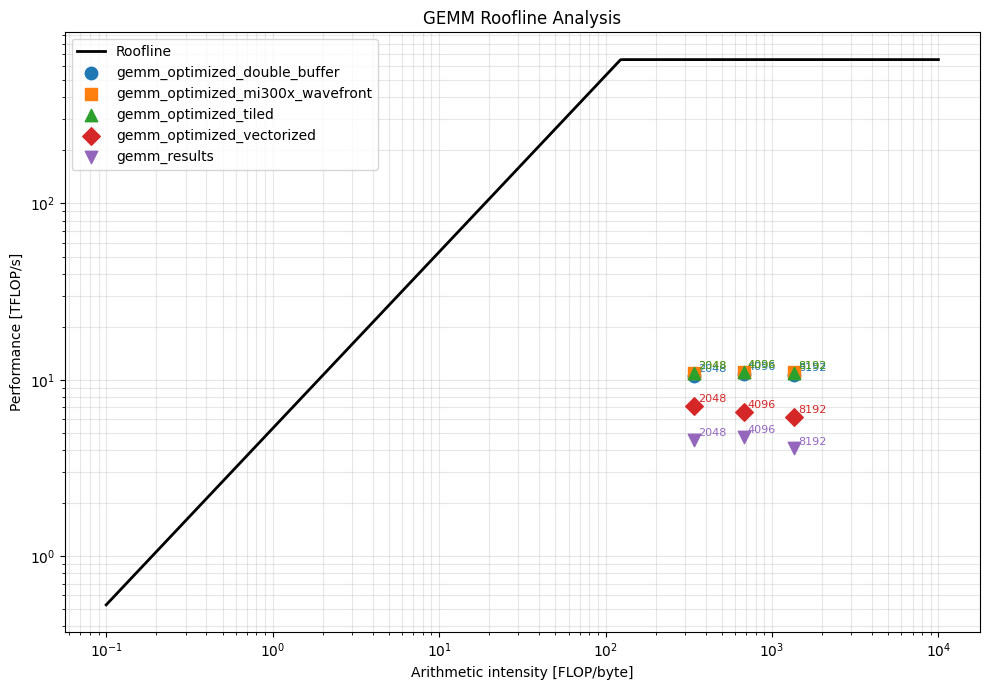

In [18]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change these for your GPU (MI300X defaults)
peak_tflops = 653.7
memory_bandwidth_tbps = 5.3

# Roofline curve
ai = np.logspace(-1, 4, 200)
roofline = np.minimum(peak_tflops, ai * memory_bandwidth_tbps)

plt.figure(figsize=(10, 7))
plt.loglog(ai, roofline, "k-", linewidth=2, label="Roofline")

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
colors = plt.cm.tab10.colors

for i, path in enumerate(sorted(glob.glob("*.csv"))):
    df = pd.read_csv(path)
    if "AI" not in df.columns or "TFLOPS" not in df.columns:
        continue
    label = path.replace(".csv", "")
    m = markers[i % len(markers)]
    c = colors[i % len(colors)]
    print(df)
    avg_tflops = df["TFLOPS"].mean()
    print(f"Average TFLOPS of {len(df)} GEMMs: {avg_tflops:.3f}")
    plt.scatter(df["AI"], df["TFLOPS"], marker=m, color=c, s=80, zorder=3, label=label)
    for _, row in df.iterrows():
        plt.text(row["AI"] * 1.05, row["TFLOPS"] * 1.05, f'{int(row["M"])}',
                 fontsize=8, color=c)

plt.xlabel("Arithmetic intensity [FLOP/byte]")
plt.ylabel("Performance [TFLOP/s]")
plt.title("GEMM Roofline Analysis")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("gemm_roofline.png", dpi=200)
plt.show()
